# Lasso and Ridge Regression


In [58]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge, LinearRegression, Lasso

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error

In [59]:
data = {

    "Area": [800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700],

    "Bedrooms": [1, 2, 2, 2, 3, 3, 3, 4, 4, 4],
  
    "Bathrooms": [1, 1, 2, 2, 2, 2, 3, 3, 3, 3],

    "Age": [15, 12, 10, 8, 6, 5, 4, 3, 2, 1],

    "Distance_City": [15, 14, 13, 12, 10, 9, 8, 7, 6, 5],
                      
    "Price": [40,50, 55,60,70, 79,80,90,95,100]   
}
df = pd.DataFrame(data)                  

In [60]:
X = df.drop("Price",axis=1)

In [61]:
Y = df["Price"]

In [62]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2,random_state=42)


In [63]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)                                                
                                                 

In [64]:
linear=LinearRegression()
linear.fit(X_train_scaled,Y_train)

LinearRegression()

In [65]:
ridge=Ridge(alpha=2.0)
ridge.fit(X_train_scaled,Y_train)

Ridge(alpha=2.0)

In [66]:
y_train_pred_lin = linear.predict(X_train_scaled)

y_test_pred_lin = linear.predict(X_test_scaled)

In [67]:
train_mse_lin = mean_squared_error(Y_train, Y_train_pred_lin)

test_mse_lin = mean_squared_error(Y_test, Y_test_pred_lin)

print("Train MSE:", train_mse_lin)
print("Test MSE:", test_mse_lin)

Train MSE: 0.9116809116809057
Test MSE: 0.4398016249868052


In [68]:
y_train_pred_rid = ridge.predict(X_train_scaled)

y_test_pred_rid = ridge.predict(X_test_scaled)

In [69]:
train_mse_rid = mean_squared_error(Y_train, Y_train_pred_rid)

test_mse_rid = mean_squared_error(Y_test, Y_test_pred_rid)

print("Train MSE:", train_mse_rid)
print("Test MSE:", test_mse_rid)

Train MSE: 4.097542380551486
Test MSE: 1.4994583596374367


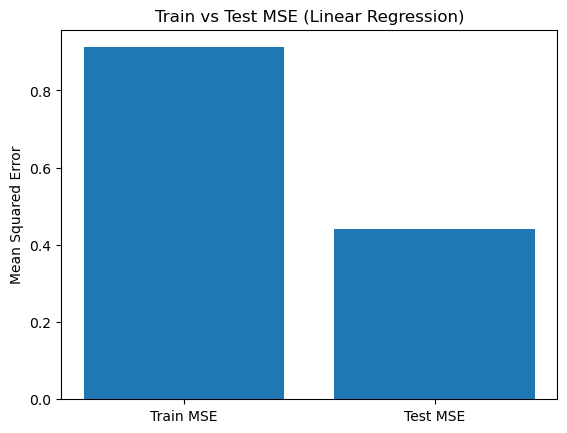

In [70]:
plt.bar(["Train MSE","Test MSE"],[train_mse_lin,test_mse_lin])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Linear Regression)")
plt.show()

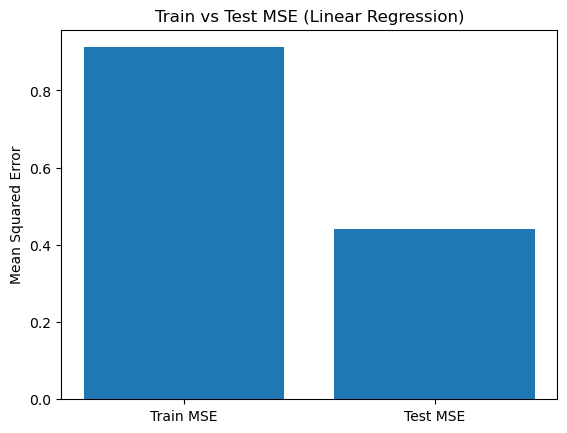

In [71]:
plt.bar(["Train MSE","Test MSE"],[train_mse_lin,test_mse_lin])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Linear Regression)")
plt.show()

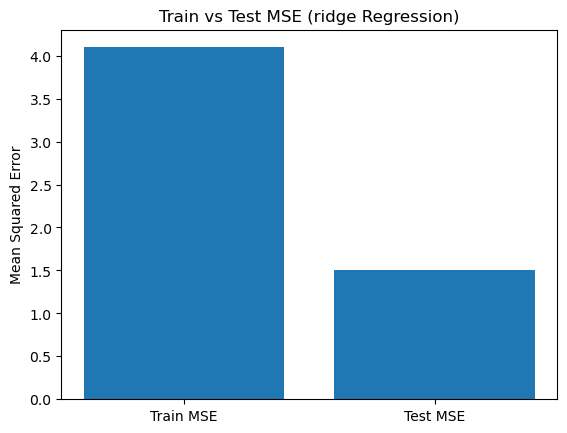

In [72]:
plt.bar(["Train MSE","Test MSE"],[train_mse_rid,test_mse_rid])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (ridge Regression)")
plt.show()

# Lasso Regularization

In [95]:
lasso = Lasso(alpha=0.5)
lasso.fit(X_train_scaled,Y_train)

Lasso(alpha=0.5)

In [100]:
Y_train_pred=lasso.predict(X_train_scaled)
Y_test_pred = lasso.predict(Y_test_scaled)


In [101]:
Train_MSE_Lasso = mean_squared_error(Y_train, Y_train_pred)
Test_MSE_Lasso = mean_squared_error(Y_test, Y_test_pred)
print("Train MSE:", Train_MSE_Lasso)
print("Test MSE:", Test_MSE_Lasso)

Train MSE: 1.5961982663459748
Test MSE: 0.19446628603333038


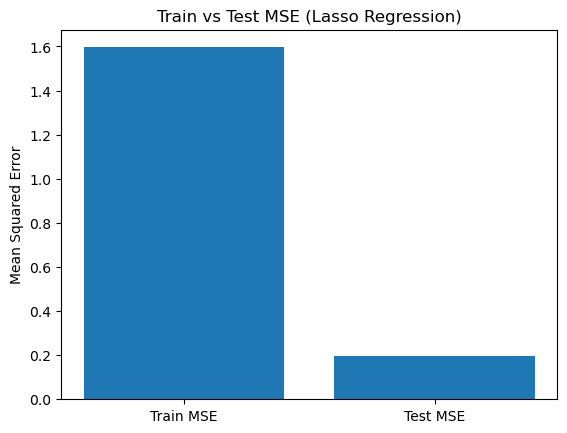

In [103]:
plt.bar(["Train MSE", "Test MSE"], [Train_MSE_Lasso, Test_MSE_Lasso])
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE (Lasso Regression)")
plt.show()

In [105]:
lasso_coefficients=pd.Series(lasso.coef_,index=X.columns)
print(lasso_coefficients)

Area             6.442610
Bedrooms         3.481834
Bathrooms        0.000000
Age             -1.291888
Distance_City   -6.688367
dtype: float64


In [113]:
X_plot=pd.DataFrame({
    "Area":np.linspace(df["Area"].min(),df["Area"].max(),100),
    "Bedrooms": df["Bedrooms"].mean(),
    "Bathrooms":df["Bathrooms"].mean(),
    "Age": df["Age"].mean(),
    "Distance_City": df["Distance_City"].mean()
    })

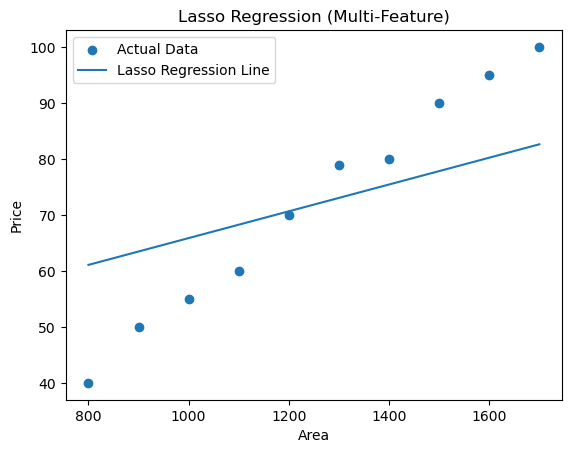

In [115]:
x_plot_scaled=scaler.transform(X_plot)
y_line=lasso.predict(x_plot_scaled)
plt.scatter(df["Area"],df["Price"],label="Actual Data")
plt.plot(X_plot["Area"],y_line,label="Lasso Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Lasso Regression (Multi-Feature)")
plt.legend()
plt.show()

